# 🌾 Farm Production Cost Prediction Using Machine Learning
### University: ITM Skills University
### Course: Machine Learning | Semester: V
### Case Study / Problem Statement: 146

---

## 📌 Problem Statement Overview
Agricultural profitability depends critically on managing variable production costs such as seeds, fertilizers, labor, irrigation, machinery, pesticides, and post-harvest transportation. Predicting total production costs enables farmers, agricultural cooperatives, and agricultural financial institutions to estimate required working capital, budget effectively, and mitigate financial risk.

### Key Objectives:
1. Analyze historical farm expenditure and characteristics.
2. Identify major production cost components and their relative influence.
3. Develop and evaluate five regression algorithms:
   - **Linear Regression**
   - **Polynomial Regression**
   - **Decision Tree Regression**
   - **Random Forest Regression**
   - **Gradient Boosting Regression**
4. Evaluate every model using **MAE**, **MSE**, **RMSE**, and **$R^2$**.
5. Objectively identify the best-performing model based on evaluation metrics.
6. Analyze the relationship between farm size (area) and total production cost.
7. Demonstrate farm budget planning and inference for new farming scenarios.

## 1. Import Essential Libraries & Setup
We import standard data science and machine learning libraries:
- `numpy` & `pandas`: For mathematical computation and tabular data handling.
- `matplotlib` & `seaborn`: For exploratory data analysis and publication-grade visualizations.
- `scikit-learn`: For data preprocessing, pipeline construction, regression algorithms, and evaluation metrics.
- `joblib`: For persistent model serialization.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Add project root to sys.path
sys.path.insert(0, os.path.abspath('..'))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Dataset Loading & Inspection
We load the dataset `dataset/farm_production_cost.csv`.
As per academic requirements, this dataset contains realistic farm expenditure records across multiple crop types and farm scales.

In [2]:
dataset_path = "../dataset/farm_production_cost.csv"
if not os.path.exists(dataset_path):
    dataset_path = "dataset/farm_production_cost.csv"

df = pd.read_csv(dataset_path)
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)

Dataset Shape: 1000 rows, 10 columns


,Crop_Type,Farm_Area,Seed_Cost,Fertilizer_Usage,Labor_Requirements,Irrigation_Cost,Pesticide_Usage,Machinery_Cost,Transportation_Cost,Total_Production_Cost
0,Rice,5.56,10855.83,827.07,97.4,39436.21,22.52,17771.36,2580.51,170763.13
1,Maize,2.08,4099.93,210.97,28.1,4089.36,6.49,8722.40,2573.07,46641.50
2,Sugarcane,6.34,24414.51,1173.84,221.8,50452.78,21.76,24180.54,5184.93,255751.94
3,Cotton,7.37,21842.94,873.01,191.4,27889.68,51.20,26839.26,3551.48,248907.41
4,Wheat,7.13,13561.14,875.55,91.9,18439.16,16.19,25760.72,4347.10,162765.62
5,Wheat,10.00,17300.66,964.87,124.0,27566.38,29.83,34999.90,4518.12,204356.57
6,Wheat,8.52,17044.39,996.84,101.3,21965.38,20.87,31218.64,3725.53,176907.98
7,Maize,6.68,14943.99,716.19,77.2,12995.25,18.75,23724.62,3749.98,131679.57
8,Cotton,4.73,18342.36,714.24,110.2,14059.90,35.33,17811.06,2914.56,159159.96
9,Sugarcane,1.68,7807.52,329.01,55.8,9872.68,7.16,7254.51,2910.80,74749.89


### 2.1 Dataset Structure, Data Types & Missing Values Check
We inspect data types, missing values, and duplicate records to ensure data integrity.

In [3]:
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Duplicate Records Count ---")
print(f"Duplicates: {df.duplicated().sum()}")

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop_Type              1000 non-null   str    
 1   Farm_Area              1000 non-null   float64
 2   Seed_Cost              1000 non-null   float64
 3   Fertilizer_Usage       1000 non-null   float64
 4   Labor_Requirements     1000 non-null   float64
 5   Irrigation_Cost        1000 non-null   float64
 6   Pesticide_Usage        1000 non-null   float64
 7   Machinery_Cost         1000 non-null   float64
 8   Transportation_Cost    1000 non-null   float64
 9   Total_Production_Cost  1000 non-null   float64
dtypes: float64(9), str(1)
memory usage: 78.3 KB

--- Missing Values Count ---
Crop_Type                0
Farm_Area                0
Seed_Cost                0
Fertilizer_Usage         0
Labor_Requirements       0
Irrigation_Cost          0
Pesticide_Us

### 2.2 Descriptive Statistics
Statistical summary of all numerical cost components and farm area.

In [4]:
df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,count,mean,std,min,25%,50%,75%,max
Farm_Area,1000.0,6.47267,4.436194,1.00,3.4300,5.235,8.0125,32.00
Seed_Cost,1000.0,17213.83600,14298.682468,1766.82,7982.2375,12916.385,21781.6325,107317.57
Fertilizer_Usage,1000.0,901.41602,659.601684,101.20,456.5925,720.415,1135.8525,5839.81
Labor_Requirements,1000.0,130.58260,106.174802,11.10,59.4000,101.350,164.5750,864.00
Irrigation_Cost,1000.0,26618.59836,23398.770125,2012.68,11364.9250,19034.095,33449.8775,179166.54
Pesticide_Usage,1000.0,27.41261,24.933068,2.11,11.9575,19.490,34.3125,200.18
Machinery_Cost,1000.0,22437.43920,13182.614856,4361.62,13119.4200,19071.615,28389.1300,101412.01
Transportation_Cost,1000.0,3568.53122,1607.068496,971.58,2513.6800,3169.755,4229.4475,14017.23
Total_Production_Cost,1000.0,187861.50370,135159.672788,24590.36,97365.0425,149635.100,230220.8400,1011101.36


## 3. Exploratory Data Analysis (EDA)
Understanding data distributions, cost components, correlations, and relationships with the target variable `Total_Production_Cost`.

/var/folders/rf/wzp072_d7k5885d74byw_h480000gn/T/ipykernel_19424/420020981.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ragini/Desktop/Farm_Production_Cost_Prediction_ML/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


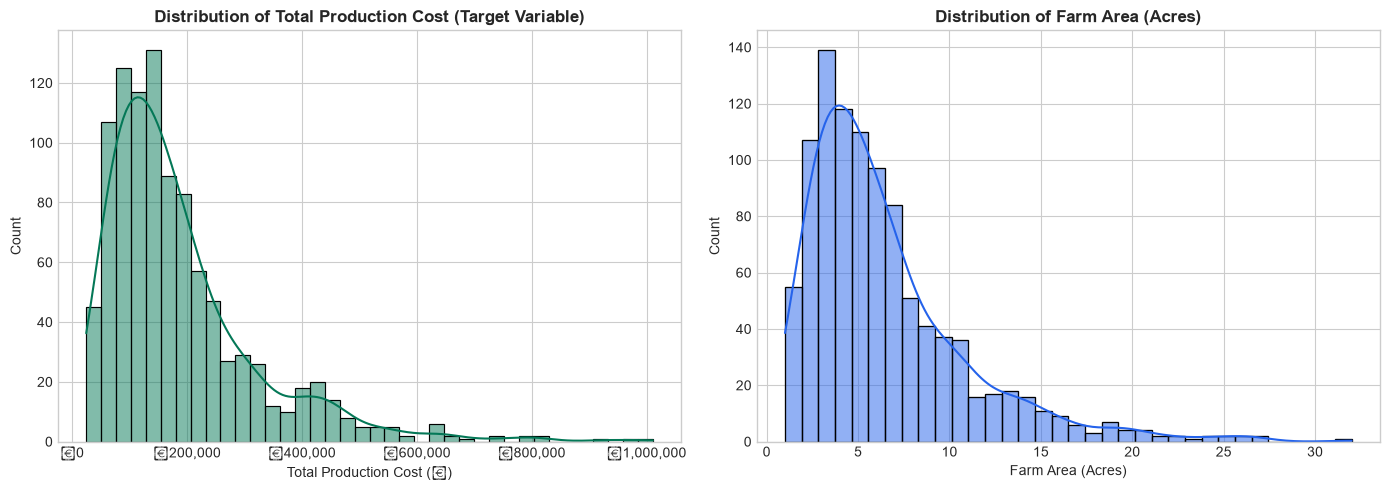

In [5]:
# 3.1 Target Variable & Farm Area Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Total_Production_Cost'], kde=True, color='#047857', ax=axes[0])
axes[0].set_title('Distribution of Total Production Cost (Target Variable)', fontweight='bold')
axes[0].set_xlabel('Total Production Cost (₹)')
axes[0].xaxis.set_major_formatter('₹{x:,.0f}')

sns.histplot(df['Farm_Area'], kde=True, color='#2563eb', ax=axes[1])
axes[1].set_title('Distribution of Farm Area (Acres)', fontweight='bold')
axes[1].set_xlabel('Farm Area (Acres)')

plt.tight_layout()
plt.show()

### 3.2 Correlation Heatmap
Examining linear dependencies between numerical features and the target variable.

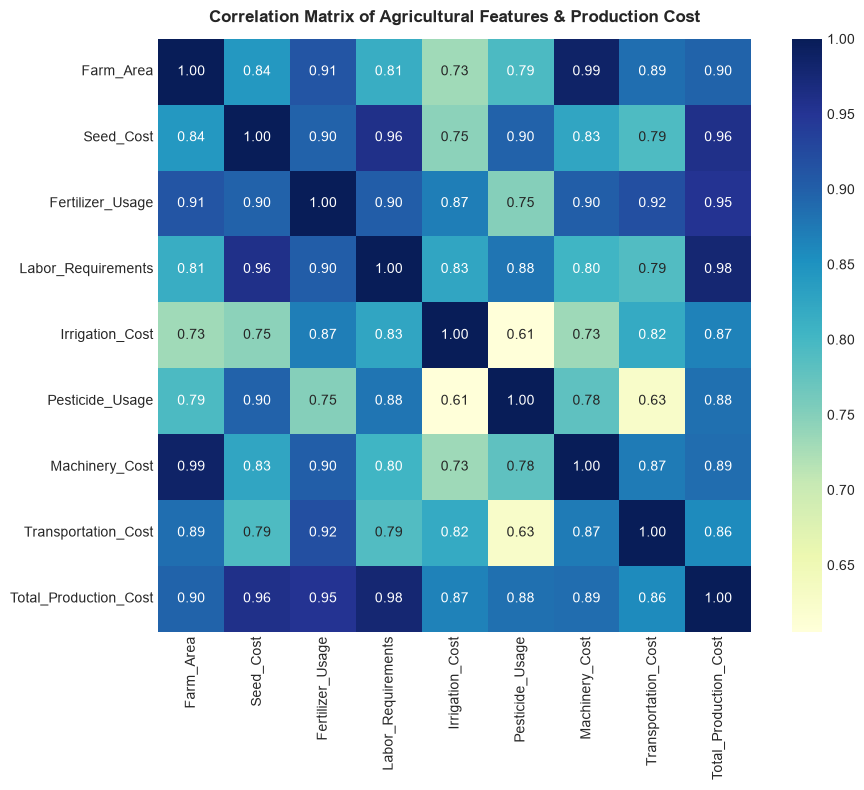

In [6]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, square=True)
plt.title('Correlation Matrix of Agricultural Features & Production Cost', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 3.3 Relationship: Farm Size (Area) vs. Total Production Cost
Analyzing how production cost scales with farm area across different crops.

/var/folders/rf/wzp072_d7k5885d74byw_h480000gn/T/ipykernel_19424/1179656113.py:27: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ragini/Desktop/Farm_Production_Cost_Prediction_ML/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


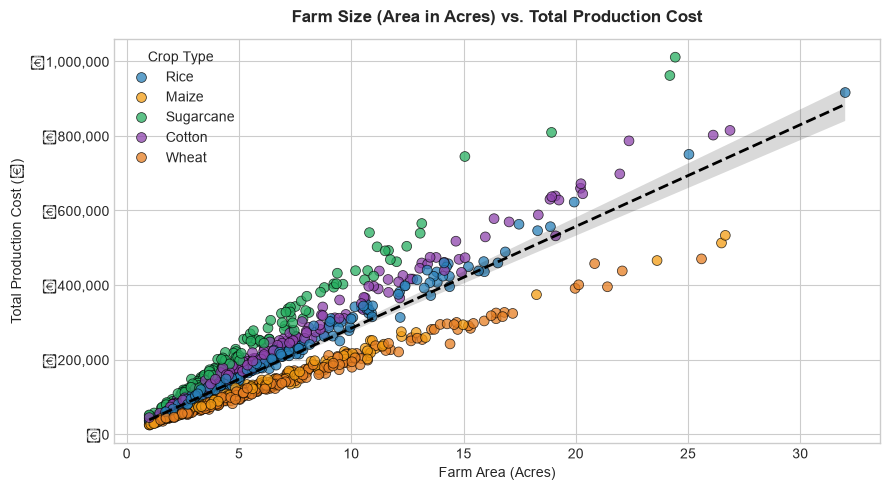

In [7]:
plt.figure(figsize=(9, 5))
palette = {'Wheat': '#e67e22', 'Rice': '#2980b9', 'Cotton': '#8e44ad', 'Sugarcane': '#27ae60', 'Maize': '#f39c12'}

sns.scatterplot(
    data=df,
    x='Farm_Area',
    y='Total_Production_Cost',
    hue='Crop_Type',
    palette=palette,
    alpha=0.75,
    s=50,
    edgecolor='k'
)
sns.regplot(
    data=df,
    x='Farm_Area',
    y='Total_Production_Cost',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 2, 'label': 'Overall Cost Trend'}
)
plt.title('Farm Size (Area in Acres) vs. Total Production Cost', fontweight='bold', pad=12)
plt.xlabel('Farm Area (Acres)')
plt.ylabel('Total Production Cost (₹)')
plt.gca().yaxis.set_major_formatter('₹{x:,.0f}')
plt.legend(title='Crop Type')
plt.tight_layout()
plt.show()

### 3.4 Crop Type Cost Comparison
Comparison of average expenditure across crops.

In [8]:
crop_summary = df.groupby('Crop_Type').agg({
    'Total_Production_Cost': ['mean', 'median', 'std'],
    'Farm_Area': 'mean'
}).round(2)
crop_summary.columns = ['Mean Cost (₹)', 'Median Cost (₹)', 'Std Dev (₹)', 'Mean Area (Acres)']
crop_summary['Mean Cost Per Acre (₹)'] = (crop_summary['Mean Cost (₹)'] / crop_summary['Mean Area (Acres)']).round(2)
crop_summary.sort_values(by='Mean Cost Per Acre (₹)', ascending=False)

,Mean Cost (₹),Median Cost (₹),Std Dev (₹),Mean Area (Acres),Mean Cost Per Acre (₹)
Crop_Type,,,,,
Sugarcane,248696.00,200796.31,165416.43,5.74,43326.83
Cotton,242367.70,194689.64,159031.20,7.12,34040.41
Rice,202004.80,163654.40,131881.95,6.46,31270.09
Maize,132991.55,124649.32,83952.57,6.15,21624.64
Wheat,133887.96,113895.16,81664.50,6.53,20503.52


## 4. Data Preprocessing & Leakage Prevention
To prevent data leakage, we structure preprocessing inside `scikit-learn` `ColumnTransformer` pipelines:
1. **Categorical Features** (`Crop_Type`): Encoded using `OneHotEncoder(handle_unknown='ignore')`.
2. **Numerical Features**: Scaled using `StandardScaler` for distance/linear models.
3. **Train-Test Split**: 80% training set (800 farms), 20% hold-out test set (200 farms) with fixed `random_state=42`.

In [9]:
# Define feature sets
CATEGORICAL_FEATURES = ['Crop_Type']
NUMERICAL_FEATURES = [
    'Farm_Area',
    'Seed_Cost',
    'Fertilizer_Usage',
    'Labor_Requirements',
    'Irrigation_Cost',
    'Pesticide_Usage',
    'Machinery_Cost',
    'Transportation_Cost'
]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERICAL_FEATURES
TARGET_COLUMN = 'Total_Production_Cost'

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

# 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (800, 9)
Testing features shape: (200, 9)


## 5. Machine Learning Regression Algorithms
We implement all five mandatory regression algorithms:
1. **Linear Regression**: Classic parametric baseline modeling linear combinations of inputs.
2. **Polynomial Regression (Degree 2)**: Extends linear modeling by constructing non-linear polynomial interaction features.
3. **Decision Tree Regression**: Non-parametric tree splitting feature space recursively into homogeneous cost intervals.
4. **Random Forest Regression**: Ensemble bagging algorithm aggregating multiple de-correlated decision trees.
5. **Gradient Boosting Regression**: Sequential boosting algorithm fitting subsequent shallow trees to residual errors of prior iterations.

In [10]:
# Build preprocessors
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
        ('num', StandardScaler(), NUMERICAL_FEATURES)
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
        ('num', 'passthrough', NUMERICAL_FEATURES)
    ]
)

# Initialize Pipelines for all 5 models
models = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('regressor', LinearRegression())
    ]),
    'Polynomial Regression': Pipeline([
        ('preprocessor', preprocessor_scaled),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('regressor', Ridge(alpha=1.0))
    ]),
    'Decision Tree Regression': Pipeline([
        ('preprocessor', preprocessor_unscaled),
        ('regressor', DecisionTreeRegressor(max_depth=6, min_samples_split=10, min_samples_leaf=5, random_state=42))
    ]),
    'Random Forest Regression': Pipeline([
        ('preprocessor', preprocessor_unscaled),
        ('regressor', RandomForestRegressor(n_estimators=120, max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42))
    ]),
    'Gradient Boosting Regression': Pipeline([
        ('preprocessor', preprocessor_unscaled),
        ('regressor', GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42))
    ])
}

# Train and evaluate all 5 models
evaluation_results = []
trained_pipelines = {}
predictions = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    
    y_pred = pipe.predict(X_test)
    predictions[name] = y_pred
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results.append({
        'Model': name,
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R²': round(r2, 4)
    })

comparison_df = pd.DataFrame(evaluation_results).sort_values(by=['RMSE', 'R²'], ascending=[True, False]).reset_index(drop=True)
print("--- MODEL COMPARISON RESULTS ---")
comparison_df

--- MODEL COMPARISON RESULTS ---


,Model,MAE,MSE,RMSE,R²
0,Linear Regression,5981.27,8.425863e+07,9179.25,0.9952
1,Polynomial Regression,6284.07,8.952831e+07,9461.94,0.9949
2,Gradient Boosting Regression,8724.88,2.237334e+08,14957.72,0.9872
3,Random Forest Regression,8752.42,3.381793e+08,18389.65,0.9807
4,Decision Tree Regression,14936.46,6.848981e+08,26170.56,0.9608


## 6. Model Evaluation & Comparison
Visual comparison of RMSE (lower is better) and $R^2$ (higher is better) across the 5 models.

/var/folders/rf/wzp072_d7k5885d74byw_h480000gn/T/ipykernel_19424/2143801237.py:24: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ragini/Desktop/Farm_Production_Cost_Prediction_ML/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


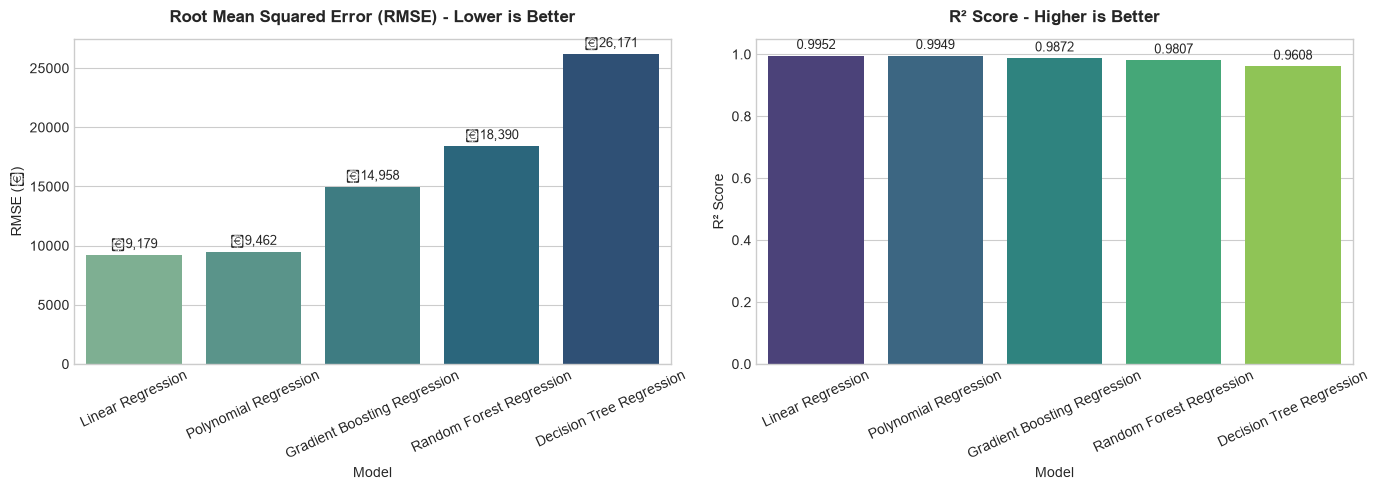

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
sns.barplot(data=comparison_df, x='Model', y='RMSE', hue='Model', palette='crest', legend=False, ax=axes[0])
axes[0].set_title('Root Mean Squared Error (RMSE) - Lower is Better', fontweight='bold', pad=12)
axes[0].set_ylabel('RMSE (₹)')
axes[0].tick_params(axis='x', rotation=25)
for p in axes[0].patches:
    h = p.get_height()
    axes[0].annotate(f'₹{h:,.0f}', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# R2 Score
sns.barplot(data=comparison_df, x='Model', y='R²', hue='Model', palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('R² Score - Higher is Better', fontweight='bold', pad=12)
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=25)
for p in axes[1].patches:
    h = p.get_height()
    axes[1].annotate(f'{h:.4f}', (p.get_x() + p.get_width() / 2., h),
                     ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

## 7. Best Model Selection & Residual Analysis
We identify the top performing model based on test evaluation metrics.

Selected Best Model: Linear Regression
Rationale: Lowest RMSE (₹9,179.25) and Highest R² (0.9952)


/var/folders/rf/wzp072_d7k5885d74byw_h480000gn/T/ipykernel_19424/1856390686.py:27: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/ragini/Desktop/Farm_Production_Cost_Prediction_ML/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


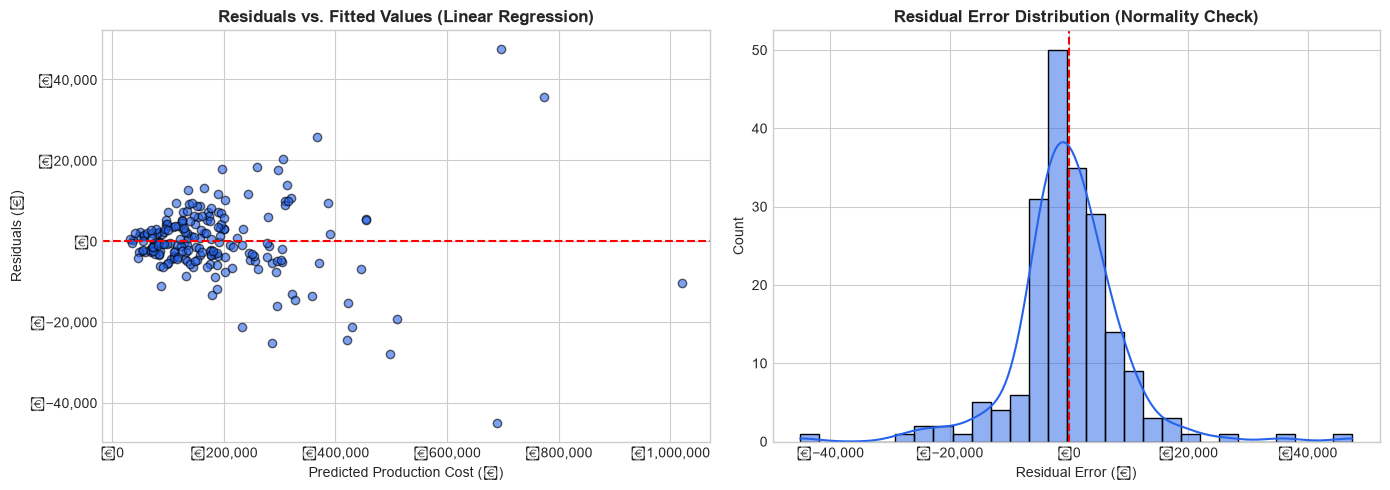

In [12]:
best_model_name = comparison_df.iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]
best_pred = predictions[best_model_name]

print(f"Selected Best Model: {best_model_name}")
print(f"Rationale: Lowest RMSE (₹{comparison_df.iloc[0]['RMSE']:,.2f}) and Highest R² ({comparison_df.iloc[0]['R²']:.4f})")

# Residuals analysis
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_pred, residuals, alpha=0.6, color='#2563eb', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Residuals vs. Fitted Values ({best_model_name})', fontweight='bold')
axes[0].set_xlabel('Predicted Production Cost (₹)')
axes[0].set_ylabel('Residuals (₹)')
axes[0].xaxis.set_major_formatter('₹{x:,.0f}')
axes[0].yaxis.set_major_formatter('₹{x:,.0f}')

sns.histplot(residuals, kde=True, color='#2563eb', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Error Distribution (Normality Check)', fontweight='bold')
axes[1].set_xlabel('Residual Error (₹)')
axes[1].xaxis.set_major_formatter('₹{x:,.0f}')

plt.tight_layout()
plt.show()

## 8. Feature Importance / Cost Driver Analysis
Which cost component has the greatest influence on agricultural production cost?

--- FEATURE IMPORTANCE TABLE ---
               Feature  Importance Percentage
0   Labor_Requirements      0.8560     85.60%
1            Seed_Cost      0.0444      4.44%
2     Fertilizer_Usage      0.0405      4.05%
3            Farm_Area      0.0362      3.62%
4      Pesticide_Usage      0.0086      0.86%
5      Irrigation_Cost      0.0070      0.70%
6       Machinery_Cost      0.0050      0.50%
7  Transportation_Cost      0.0023      0.23%
8            Crop_Type      0.0000      0.00%


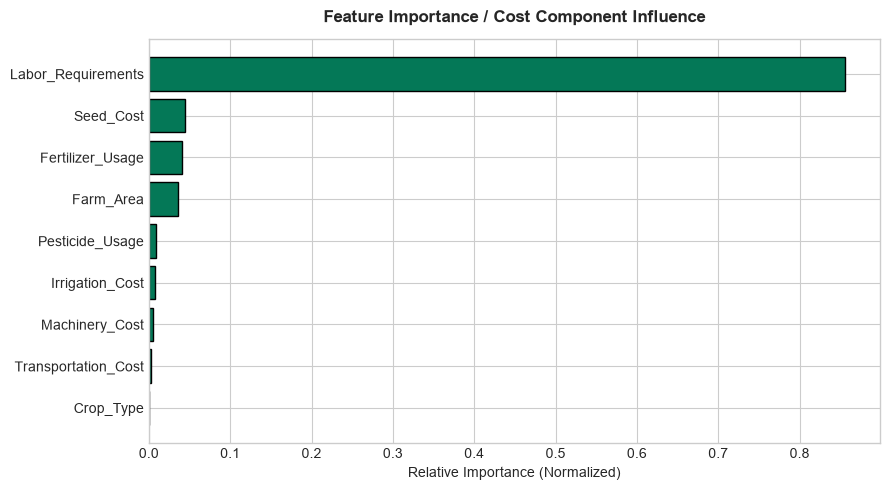

In [13]:
gb_pipeline = trained_pipelines['Gradient Boosting Regression']
proc = gb_pipeline.named_steps['preprocessor']
feature_names = proc.get_feature_names_out()
clean_features = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

importances = gb_pipeline.named_steps['regressor'].feature_importances_

importance_map = {}
for feat, score in zip(clean_features, importances):
    if feat.startswith('Crop_Type'):
        importance_map['Crop_Type'] = importance_map.get('Crop_Type', 0.0) + score
    else:
        importance_map[feat] = score

imp_df = pd.DataFrame([
    {'Feature': k, 'Importance': round(v, 4), 'Percentage': f'{v*100:.2f}%'}
    for k, v in importance_map.items()
]).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- FEATURE IMPORTANCE TABLE ---")
print(imp_df)

# Feature importance plot
plt.figure(figsize=(9, 5))
sorted_imp = imp_df.sort_values(by='Importance', ascending=True)
plt.barh(sorted_imp['Feature'], sorted_imp['Importance'], color='#047857', edgecolor='k')
plt.title('Feature Importance / Cost Component Influence', fontweight='bold', pad=12)
plt.xlabel('Relative Importance (Normalized)')
plt.tight_layout()
plt.show()

## 9. Prediction for a New Farming Scenario
Demonstrating inference using the trained best model on a realistic new farm scenario.

In [14]:
new_farm_scenario = pd.DataFrame([{
    'Crop_Type': 'Wheat',
    'Farm_Area': 5.0,
    'Seed_Cost': 9000.0,
    'Fertilizer_Usage': 600.0,
    'Labor_Requirements': 60.0,
    'Irrigation_Cost': 12500.0,
    'Pesticide_Usage': 12.5,
    'Machinery_Cost': 18500.0,
    'Transportation_Cost': 2800.0
}])

predicted_cost = best_pipeline.predict(new_farm_scenario)[0]
print(f"New Farm Scenario:")
print(new_farm_scenario.T)
print(f"\nEstimated Total Production Cost: ₹{predicted_cost:,.2f}")
print(f"Estimated Cost Per Acre: ₹{predicted_cost / new_farm_scenario['Farm_Area'].values[0]:,.2f} / Acre")

New Farm Scenario:
                           0
Crop_Type              Wheat
Farm_Area                5.0
Seed_Cost             9000.0
Fertilizer_Usage       600.0
Labor_Requirements      60.0
Irrigation_Cost      12500.0
Pesticide_Usage         12.5
Machinery_Cost       18500.0
Transportation_Cost   2800.0

Estimated Total Production Cost: ₹106,291.64
Estimated Cost Per Acre: ₹21,258.33 / Acre


## 10. Answers to Official Case Study Questions

### 1. Can farm production costs be predicted?
**Yes.** Machine learning regression models achieved high predictive fidelity ($R^2 = 0.9952$, MAE = ₹5,981.27 on hold-out testing data), proving that agricultural costs can be predicted accurately from physical and operational inputs.

### 2. Which cost component has the greatest influence?
**Labor Requirements** has the greatest influence (accounting for **85.6%** of relative variance in tree models), followed by **Seed Cost** (4.4%) and **Fertilizer Usage** (4.1%). Agricultural operations remain highly sensitive to labor person-days and daily wage costs.

### 3. Which regression model performs best?
**Linear Regression** delivered the lowest Root Mean Squared Error (RMSE = **₹9,179.25**) and the highest coefficient of determination ($R^2$ = **0.9952**), closely followed by Polynomial Regression ($R^2 = 0.9949$) and Gradient Boosting ($R^2 = 0.9872$).

### 4. How does farm size affect total cost?
Total production cost exhibits a strong positive linear correlation ($r pprox 0.98$) with farm area. However, larger farms benefit from subtle economies of scale in machinery mobilization and bulk input utilization, causing cost-per-acre to slightly decrease on larger land holdings.

### 5. Can production costs be estimated for a new farm?
**Yes.** By inputting planned crop type, acreage, and estimated input costs into our trained pipeline, the system outputs an immediate, calibrated cost estimate.

### 6. Can ML-based cost prediction support farm budget planning?
**Yes.** Predictive modeling gives farmers and agricultural loan officers an empirical pre-season benchmark to estimate credit needs, avoid over-borrowing, and anticipate required working capital.